
# 19 — Linear response: the velocity operator, the Sternheimer equation, and $\varepsilon_\infty$

Everything so far has been a *ground state*: a total energy, and derivatives of it with
respect to where the atoms are (P15) or how the cell is strained (P11). This notebook is
about how the ground state **responds** — to a shift of the crystal momentum, to a change
in the potential, and to a uniform electric field.

All three are the same thing seen at different depths, and the point of the phase is that
**almost none of it is derived by hand**:

| | what QE does | what happens here |
|---|---|---|
| $[H,\,\mathbf r]$, the velocity operator | `commutator_Hx_psi.f90` codes the kinetic term and the projectors' angular and radial derivatives one by one | one `jax.jvp` of $H(k)$, because $dH/dk_a = i[H, r_a]$ |
| $\chi_0 = d\rho/dV$ | a projected CG solve per occupied band | the same solve — this part *is* transcribed |
| $dV_{\rm scf}/d\rho$, the screening kernel | `dv_of_drho.f90` plus a tabulated $f_{\rm xc}$ (`setup_dmuxc`) | one `jvp` of `v_of_rho`, which is already a differentiable function of the density |
| $dV_{\rm bare}/du$, the bare phonon term | `dvqpsi_us.f90`, term by term | one `jvp` through `Calculation.at_positions` |

The headline, on the silicon cell of QE's `test-suite/ph_base` — the one `ph.x` runs with
`epsil = .true.`:

| | pypresso | `ph.x` |
|---|---|---|
| $\varepsilon_\infty$ | **13.806646** | 13.806375 |
| Born charge $Z^*$ | **−0.075715** | −0.07568 |

In [1]:
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.response import (
    VelocityOperator,
    dielectric_tensor,
    local_perturbation,
    make_sternheimer,
)
from pypresso.scf import Calculation, run_scf
from pypresso.system import build_system
from pypresso.system.kpoints import KPoints
from pypresso.units import RY_TO_EV
from pypresso.workflows import run_bands
from pypresso.workflows.nscf import fixed_density_states

CASES = Path("../tests/data/qe")
PSEUDO = Path("../tests/data/pseudo")

system = build_system(read_pw_input(CASES / "si-epsilon.in"))
pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
calculation = Calculation(system, pseudos)
scf = run_scf(system, pseudos, calculation=calculation, conv_thr=1e-12)

print(f"total energy   {scf.total_energy:.9f} Ry")
print(f"pw.x           -15.84452726 Ry")

total energy   -15.844527263 Ry
pw.x           -15.84452726 Ry



## 1. The velocity operator

For a *local* potential the velocity operator would be $\mathbf p$, and a plane-wave code
would need nothing at all: $\langle k{+}G|\mathbf p|k{+}G\rangle = \mathbf k + \mathbf G$. A
pseudopotential is not local, and $[V_{\rm NL}, \mathbf r] \neq 0$.

In the periodic gauge $H(k) = e^{-i k\cdot r} H e^{i k\cdot r}$, so

$$ \frac{\partial H(k)}{\partial k_a} \;=\; i\,[H,\, r_a], $$

and the operator is the derivative of code that already exists. This is why
`pseudo/formfactors.py` *integrates* every radial transform rather than interpolating QE's
`dq = 0.01` table, and why `pseudo/harmonics.py` avoids `ylmr2`'s `atan2`: a table lookup or
a coordinate singularity anywhere on that path would break the chain.

One `jvp` per cartesian direction gives $v_a|\psi\rangle$ for every band at every k-point.
Nothing dense is ever formed — $dH/dk$ as a matrix costs $n_{\rm pw}^2$.

In [2]:
path = KPoints.band_path(
    [(0.5, 0.5, 0.5), (0.0, 0.0, 0.0), (1.0, 0.0, 0.0)], [30, 30, 0],
    system.cell, crystal=False,
)
bands = run_bands(system, pseudos, scf.density, kpoints=path, nbnd=8, homo=scf.homo)

calc_path, _, path_eigenvalues, path_states = fixed_density_states(
    system, pseudos, scf.density, kpoints=path, nbnd=8, conv_thr=1e-12,
)
operator = VelocityOperator(calc_path, calc_path.potential(scf.density).v_scf)
velocity = operator.band_velocities(path_states, jnp.asarray(path_eigenvalues))

print(velocity.velocities.shape, "  (nk, nbnd, 3), in Ry bohr")

(61, 8, 3)   (nk, nbnd, 3), in Ry bohr



The check that it is the right operator is a central difference of the band structure
itself: $\langle\psi|\,dH/dk - \varepsilon\, dS/dk\,|\psi\rangle$ against
$(\varepsilon(k{+}h) - \varepsilon(k{-}h))/2h$. On a generic k-point that agrees to
**1.2e-6 Ry bohr** with a norm-conserving dataset and **8.6e-7** with an ultrasoft one —
in both cases the finite difference's own truncation error
(`tests/regression/test_response.py`).

The ultrasoft case is the one that means something. $S(k) = 1 + \sum |\beta(k)\rangle q
\langle\beta(k)|$ carries the same $k$ the Hamiltonian does, so the band velocity is the
*generalised* Hellmann–Feynman derivative and $dS/dk$ is part of it. It comes out of the
same `jvp`, without a branch: exactly zero for norm-conserving, 1.5e-2 for ultrasoft.

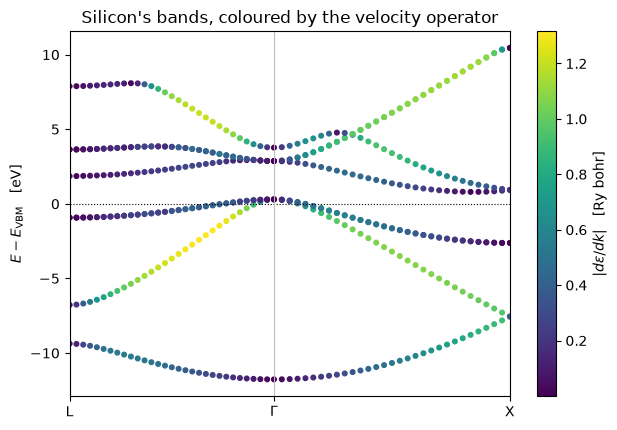

In [3]:
x = np.asarray(path.path_length)
energies = bands.eigenvalues_ev - bands.homo * RY_TO_EV
speed = velocity.speeds[0]                     # |d eps / dk|, (nk, nbnd), Ry bohr

fig, ax = plt.subplots(figsize=(6.4, 4.4))
points = ax.scatter(
    np.repeat(x[:, None], energies.shape[1], axis=1).ravel(),
    energies.ravel(), c=speed.ravel(), s=11, cmap="viridis",
)
fig.colorbar(points, ax=ax, label=r"$|d\varepsilon/dk|$   [Ry bohr]")
ax.axhline(0.0, color="k", lw=0.8, ls=":")
for vertex in (x[0], x[30], x[-1]):
    ax.axvline(vertex, color="0.75", lw=0.8)
ax.set_xticks([x[0], x[30], x[-1]])
ax.set_xticklabels(["L", r"$\Gamma$", "X"])
ax.set_ylabel(r"$E - E_{\rm VBM}$   [eV]")
ax.set_title("Silicon's bands, coloured by the velocity operator")
ax.set_xlim(x[0], x[-1])
fig.tight_layout()


The dark points are where $d\varepsilon/dk$ vanishes — $\Gamma$, the zone boundary, and
every band extremum in between — and the bright ones are the steep free-electron-like
segments. Nothing in the plot was differenced: each point is an expectation value of an
operator built by differentiating the Hamiltonian.

## 2. The Sternheimer equation

The response of a state to a perturbation is formally a sum over states,

$$ |d\psi_n\rangle = \sum_{m \neq n} |\psi_m\rangle
   \frac{\langle \psi_m | dV | \psi_n\rangle}{\varepsilon_n - \varepsilon_m}, $$

which needs every empty band and divides by a gap that closes at every degeneracy — and a
crystal is degenerate everywhere by symmetry. The same question as a linear system,

$$ (H - \varepsilon_n S + \alpha Q)\,|d\psi_n\rangle = -P_c^{+}\, dV\, |\psi_n\rangle, $$

needs no empty states at all and never divides by $\varepsilon_n - \varepsilon_m$. One
projected conjugate-gradient solve per occupied band.

In [4]:
solver = make_sternheimer(calculation, scf)

# A probe potential that is smooth, real, periodic -- and breaks the crystal's symmetry,
# so that what comes back is the response and not an average of it.
grid = calculation.basis.dense.grid
lattice = np.stack(np.meshgrid(*[np.arange(n) / n for n in grid], indexing="ij"), axis=-1)
probe = jnp.asarray(np.cos(2.0 * np.pi * (lattice @ np.array([1, 0, 0])))[None])

solution = solver.solve(local_perturbation(calculation, probe))
response = solver.response_density(solution.dpsi)

print(f"{solution.iterations} CG iterations, residual {solution.residual:.1e}")
print(f"max |chi_0 dV| = {float(jnp.abs(response).max()):.4e} electrons/bohr^3")

26 CG iterations, residual 9.5e-12
max |chi_0 dV| = 9.5119e-02 electrons/bohr^3



$\chi_0\,dV$ against a central difference of the density under the same perturbation —
two diagonalisations instead of a linear solve, sharing nothing but the Hamiltonian —
agrees to **8e-7 relative**.

This is also the exact SCF Jacobian that notebook 17 could only *difference*: $F$ maps a
density to the density its Hamiltonian produces, so $dF/d\rho = \chi_0 K$ with
$K = dV_{\rm scf}/d\rho$ free from one `jvp` of `v_of_rho`. Comparing the two turned up
something about the finite difference rather than about the solve: they agree to 4.0e-4 at
the difference's *own* optimal step, and to only 11% at the step P22 uses by default, which
sits two orders below the minimum of the usual U between truncation and noise. The
difference was noise-limited and had no way to say so.

## 3. An electric field, and $\varepsilon_\infty$

A uniform field is the one perturbation a periodic code cannot simply write down: $V =
\mathbf E \cdot \mathbf r$ is neither bounded nor lattice periodic. What *is* well defined
is $P_c\,\mathbf r|\psi\rangle$, and it is reached through the commutator — which is the
velocity operator of §1, with a factor of $-i$.

Then the induced charge screens the field, and the loop that follows is `solve_e.f90`'s.

In [5]:
efield = dielectric_tensor(
    calculation, scf.wavefunctions, scf.eigenvalues, scf.density,
)

np.set_printoptions(precision=6, suppress=True)
print("dielectric tensor, cartesian axes:")
print(efield.epsilon)
print(f"\niterations to |ddv_scf|^2 < 1e-14 : {len(efield.history)}")
print(f"departure from cubic             : {efield.anisotropy:.1e}")

dielectric tensor, cartesian axes:
[[13.806646  0.       -0.      ]
 [ 0.       13.806646  0.      ]
 [-0.       -0.       13.806646]]

iterations to |ddv_scf|^2 < 1e-14 : 18
departure from cubic             : 3.6e-15


In [6]:
comparison = [
    ("epsilon_infinity", efield.isotropic, 13.806375297),
    ("Born charge Z* (Si 1)", efield.born_charges[0, 0, 0], -0.07568),
    ("Born charge Z* (Si 2)", efield.born_charges[1, 0, 0], -0.07568),
    ("total energy [Ry]", scf.total_energy, -15.84452726),
]
print(f"{'':24s}{'pypresso':>15s}{'ph.x':>15s}{'difference':>14s}")
for name, ours, theirs in comparison:
    print(f"{name:24s}{ours:15.6f}{theirs:15.6f}{ours - theirs:14.2e}")

                               pypresso           ph.x    difference
epsilon_infinity              13.806646      13.806375      2.71e-04
Born charge Z* (Si 1)         -0.075715      -0.075680     -3.50e-05
Born charge Z* (Si 2)         -0.075715      -0.075680     -3.50e-05
total energy [Ry]            -15.844527     -15.844527     -2.56e-09



Silicon's Born effective charge is **zero by symmetry** in a converged calculation, so what
$-0.07568$ measures is a residue: $Z_{\rm val} = 4$ against an electronic part near $4.076$.
Reproducing it to the digits `ph.x` prints is a sharper test of the machinery than the
dielectric constant is, because everything has to be right for a difference of large
numbers to come out small in the same way.

The figure below is the physics behind $\varepsilon_\infty = 13.8$ rather than $1$: the
charge that piles up against the field. Averaging the induced density over the two
directions perpendicular to the field is exact in reciprocal space — it is the sum of the
Fourier components with $\mathbf G \parallel \hat x$ — and leaves a function of $x$ alone.

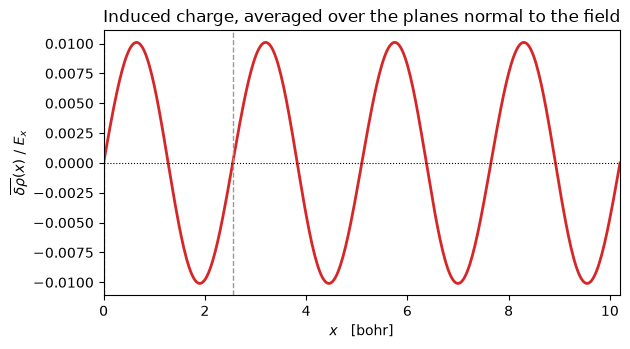

In [7]:
from pypresso.basis.fft import r_to_g

dense = calculation.basis.dense
gcart = np.asarray(dense.cartesian(system.cell))              # (ngm, 3), 1/bohr
along_x = (np.abs(gcart[:, 1]) < 1e-8) & (np.abs(gcart[:, 2]) < 1e-8)

induced_g = np.asarray(r_to_g(jnp.asarray(efield.induced_density[0, 0]), dense.fft_index))
alat = float(system.cell.alat)
grid_x = np.linspace(0.0, alat, 400)
profile = np.real(induced_g[along_x] @ np.exp(1j * np.outer(grid_x, gcart[along_x, 0])).T)

fig2, ax2 = plt.subplots(figsize=(6.4, 3.6))
ax2.plot(grid_x, profile, color="C3", lw=2.0)
ax2.axhline(0.0, color="k", lw=0.8, ls=":")
for tau in np.asarray(system.structure.positions)[:, 0] % alat:
    ax2.axvline(tau, color="0.6", lw=1.0, ls="--")
ax2.set_xlabel("$x$   [bohr]")
ax2.set_ylabel(r"$\overline{\delta\rho}(x)\ /\ E_x$")
ax2.set_title("Induced charge, averaged over the planes normal to the field")
ax2.set_xlim(0.0, alat)
fig2.tight_layout()


The dashed line is the second silicon atom; the first sits at the origin, on the left edge. The induced charge vanishes on them and is
extremal between them: the field pushes charge off one side of every bond and onto the
other, and the dipole that makes is what screens it. That the profile is very nearly a
single sinusoid says the response along $x$ is dominated by the shortest reciprocal-lattice
vector in that direction — silicon is a simple dielectric, and this is what makes it one.

## The trap, which is silent and which this phase met twice

A response is **direction-dependent**, so on a symmetry-reduced k-set the three response
densities are not what the whole grid would give, and the group has to put the difference
back (`symdvscf.f90`). What is averaged is not three scalar densities but a **polar vector
field** — the same construction the magnetization uses, without the axial sign.

The obvious escape is to run the *whole* k-grid, where a reduction has nothing to put back.
It works only if that grid is closed under the point group, and **a shifted
Monkhorst–Pack grid is not**: 2304 of the 3072 rotation images of a shifted $4\times4\times4$
grid on fcc silicon land off it. Run anyway, this cell gives a density that is 2%
asymmetric, a total energy 3.1e-5 Ry too high, and a dielectric tensor with a diagonal of
13.848 and off-diagonal entries of **3.77 that cubic symmetry forbids** — all of it looking
like a working calculation. The combination is refused by name.

On an *unshifted* grid, which is closed exactly, the escape does work — and it is the only
independent check `symmetrize_directional` has, since `ph.x` computes the wedge route
alone. The same sample reduced to 8 points and symmetrised, and whole at 64 points with the
symmetrisation switched off entirely, agree on every digit printed.

---

**Where the detail lives.** `PLAN.md` §3, phase P24 — the transcription traps, the
refusals (ultrasoft, metals, noncollinear, DFT+U) and what each one would need. The tests
are `tests/regression/test_response.py`; the code is `pypresso/response/`.